In [1]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
import itertools, os
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook, show
from bokeh.palettes import Category10
from PIL import Image
import io, base64
# output_notebook()  # <- add this

In [6]:
df_merged['Classification'].unique()

array(['budding', 'compact_irreg', 'bullet', 'agg', 'column',
       'planar_polycrystal', 'rimed'], dtype=object)

In [7]:
# load data
save_dir = '/home/jko/ssl-cpi-analysis/data/from-hari-v3'
save_filename = 'cls_env_all_merged.parquet'
save_path = os.path.join(save_dir, save_filename)
df_reload = pd.read_parquet(save_path)
df_merged = df_reload
df_merged.shape

# get a balanced subset
samples_per_class = 10000
dfs = []
habit_classes = ['budding', 'compact_irreg', 'bullet', 'agg', 'column','planar_polycrystal', 'rimed']
# habit_classes = ['bullet', 'column', 'rimed']
for cls in habit_classes:
    df_cls = df_merged[df_merged['Classification'] == cls].sample(n=samples_per_class, random_state=42)
    dfs.append(df_cls)
df_balanced = pd.concat(dfs).reset_index(drop=True)

# subset of balanced df
n_subset = 1000
df_subset = df_balanced.sample(n_subset)
emb_cols = [str(i) for i in range(384)]
X = df_subset[emb_cols]
n_components = 2
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create filepath column
df_subset['filepath'] = df_subset.apply(
    lambda row: f"/home/vanessa/hulk/cocpit/cpi_data/campaigns/{row['Campaign']}/single_imgs_v1.4.0/{row['filename']}",
    axis=1
)
df_subset[['Campaign', 'filename', 'filepath']].head()

,Campaign,filename,filepath
64577,CRYSTAL_FACE_UND,2002_0725_190403_97_0.png,/home/vanessa/hulk/cocpit/cpi_data/campaigns/C...
51553,CRYSTAL_FACE_UND,2002_0729_182007_350_57.png,/home/vanessa/hulk/cocpit/cpi_data/campaigns/C...
53352,MC3E,2011_0523_172037_1001_23.png,/home/vanessa/hulk/cocpit/cpi_data/campaigns/M...
35563,MC3E,2011_0523_173234_18_103.png,/home/vanessa/hulk/cocpit/cpi_data/campaigns/M...
18247,CRYSTAL_FACE_UND,2002_0707_185612_223_27.png,/home/vanessa/hulk/cocpit/cpi_data/campaigns/C...


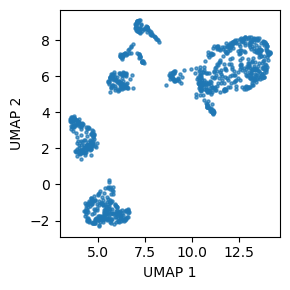

In [8]:
# perform dimensionality reduction
model = umap.UMAP(n_neighbors=100, min_dist=0.1, metric='cosine')
X_umap = model.fit_transform(X_scaled)
plt.figure(figsize=(3, 3))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()

In [10]:
# --- PARAMETERS ---
n_subset = 1000  # Set to None for full dataset, or an integer for a random subset
image_width = 100
image_quality = 50

# --- Resize + compress images for tooltip ---
def image_to_base64(path, width=100, quality=70):
    """
    Load image, resize to 'width' pixels, compress to JPEG, and return HTML <img> tag.
    """
    try:
        img = Image.open(path).convert("RGB")  # Convert to RGB to avoid PNG alpha issues
        img.thumbnail((width, width))          # Resize while preserving aspect ratio
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=quality)  # Compress to save space
        encoded = base64.b64encode(buffer.getvalue()).decode()
        return f"<img src='data:image/jpeg;base64,{encoded}' width='{width}'>"
    except Exception:
        return "<div>Image not found</div>"

# --- Apply subset if needed ---
if n_subset is not None and n_subset < len(df_subset):
    idx = np.random.choice(len(df_subset), size=n_subset, replace=False)
    df_plot = df_subset.iloc[idx]
    X_umap_plot = X_umap[idx]
else:
    df_plot = df_subset
    X_umap_plot = X_umap

# --- Map labels to colors ---
labels = df_plot['Classification'].values
unique_labels, label_codes = np.unique(labels, return_inverse=True)

# --- Convert all images to base64 ---
hover_images = df_plot['filepath'].apply(lambda p: image_to_base64(p, width=image_width, quality=image_quality))

# --- Prepare Bokeh ColumnDataSource ---
source = ColumnDataSource(data=dict(
    x=X_umap_plot[:, 0],
    y=X_umap_plot[:, 1],
    label=labels,
    color=[Category10[10][i % 10] for i in label_codes],
    img=hover_images
))

# --- Create figure ---
p = figure(width=800, height=800, title="UMAP Scatter with Hover Images")
p.scatter('x', 'y', size=6, source=source, color='color', alpha=0.7)

# --- Add hover tool ---
hover = HoverTool(tooltips="""
    <div>@img</div>
    <div><b>Label:</b> @label</div>
""")
p.add_tools(hover)

# --- Save to standalone HTML ---
output_file("umap_hover_images_subset.html", title="UMAP Scatter with Hover Images")
save(p)

print(f"✅ Saved: umap_hover_images_subset.html ({len(df_plot)} points)")


✅ Saved: umap_hover_images_subset.html (1000 points)


PCA

✅ Saved: pca_hover_images_subset_3_4.html (1000 points)


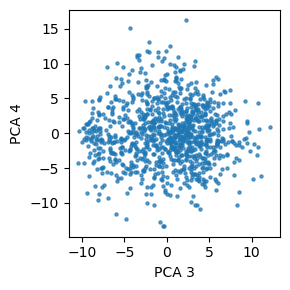

In [24]:
from sklearn.decomposition import PCA
from bokeh.plotting import figure, ColumnDataSource, output_file, save
from bokeh.models import HoverTool
from bokeh.palettes import Category10
from PIL import Image
import io, base64
import numpy as np
import matplotlib.pyplot as plt

# --- Perform PCA dimensionality reduction ---
model = PCA(n_components=5)
X_pca = model.fit_transform(X_scaled)

# --- PARAMETERS ---
n_subset = 1000  # Set to None for full dataset, or an integer for a random subset
image_width = 100
image_quality = 25
z1 = 3 # PCA dimension 1
z2 = 4 # PCA dimension 2

# Quick matplotlib plot for sanity check
plt.figure(figsize=(3, 3))
plt.scatter(X_pca[:, z1], X_pca[:, z2], s=5, alpha=0.7)
plt.xlabel(f"PCA {z1}")
plt.ylabel(f"PCA {z2}")
plt.tight_layout()

# --- Resize + compress images for tooltip ---
def image_to_base64(path, width=100, quality=70):
    """
    Load image, resize to 'width' pixels, compress to JPEG, and return HTML <img> tag.
    """
    try:
        img = Image.open(path).convert("RGB")  # Convert to RGB to avoid PNG alpha issues
        img.thumbnail((width, width))          # Resize while preserving aspect ratio
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=quality)  # Compress to save space
        encoded = base64.b64encode(buffer.getvalue()).decode()
        return f"<img src='data:image/jpeg;base64,{encoded}' width='{width}'>"
    except Exception:
        return "<div>Image not found</div>"

# --- Apply subset if needed ---
if n_subset is not None and n_subset < len(df_subset):
    idx = np.random.choice(len(df_subset), size=n_subset, replace=False)
    df_plot = df_subset.iloc[idx]
    X_pca_plot = X_pca[idx]
else:
    df_plot = df_subset
    X_pca_plot = X_pca

# --- Map labels to colors ---
labels = df_plot['Classification'].values
unique_labels, label_codes = np.unique(labels, return_inverse=True)

# --- Convert all images to base64 ---
hover_images = df_plot['filepath'].apply(lambda p: image_to_base64(p, width=image_width, quality=image_quality))

# --- Prepare Bokeh ColumnDataSource ---
source = ColumnDataSource(data=dict(
    x=X_pca_plot[:, z1],
    y=X_pca_plot[:, z2],
    label=labels,
    color=[Category10[10][i % 10] for i in label_codes],
    img=hover_images
))

# --- Create figure ---
p = figure(width=800, height=800, title="PCA Scatter with Hover Images")
p.scatter('x', 'y', size=8, source=source, color='color', alpha=0.7)

# --- Add hover tool ---
hover = HoverTool(tooltips="""
    <div>@img</div>
    <div><b>Label:</b> @label</div>
""")
p.add_tools(hover)

# --- Save to standalone HTML ---
output_file(f"pca_hover_images_subset_{z1}_{z2}.html", title="PCA Scatter with Hover Images")
save(p)

print(f"✅ Saved: pca_hover_images_subset_{z1}_{z2}.html ({len(df_plot)} points)")